In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfTransformer

In [2]:
data = pd.read_csv("../data/snsdata.csv")
data.head()

,gradyear,gender,age,friends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2006,M,18.982,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2006,F,18.801,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,2006,M,18.335,69,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,2006,F,18.875,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2006,NaN,18.995,10,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,1,1


In [3]:
# Variables de caracterización:
# - gradyear: año de graduación;
# - gender: género;
# - age: edad;
# - friends`: número de amigos.

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 40 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   gradyear      30000 non-null  int64  
 1   gender        27276 non-null  object 
 2   age           24914 non-null  float64
 3   friends       30000 non-null  int64  
 4   basketball    30000 non-null  int64  
 5   football      30000 non-null  int64  
 6   soccer        30000 non-null  int64  
 7   softball      30000 non-null  int64  
 8   volleyball    30000 non-null  int64  
 9   swimming      30000 non-null  int64  
 10  cheerleading  30000 non-null  int64  
 11  baseball      30000 non-null  int64  
 12  tennis        30000 non-null  int64  
 13  sports        30000 non-null  int64  
 14  cute          30000 non-null  int64  
 15  sex           30000 non-null  int64  
 16  sexy          30000 non-null  int64  
 17  hot           30000 non-null  int64  
 18  kissed        30000 non-nu

In [4]:
# Calidad de datos:

data[["gradyear", "gender", "age", "friends"]].describe(include="all")

,gradyear,gender,age,friends
count,30000.000000,27276,24914.000000,30000.000000
unique,NaN,2,NaN,NaN
top,NaN,F,NaN,NaN
freq,NaN,22054,NaN,NaN
mean,2007.500000,NaN,17.993950,30.179467
std,1.118053,NaN,7.858054,36.530877
min,2006.000000,NaN,3.086000,0.000000
25%,2006.750000,NaN,16.312000,3.000000
50%,2007.500000,NaN,17.287000,20.000000
75%,2008.250000,NaN,18.259000,44.000000


In [5]:
# Diagnóstico de la variable edad:

print("Edades faltantes:", data["age"].isna().sum())
print("Edad mínima:", data["age"].min())
print("Edad máxima:", data["age"].max())

Edades faltantes: 5086
Edad mínima: 3.086
Edad máxima: 106.927


In [6]:
# Remoción de datos con edades fuera del rango de 13 a 20 años (inclusive):

data["age_clean"] = data["age"].where(data["age"].between(13, 20, inclusive="left"))

age_by_gradyear = (
    data.groupby("gradyear")["age_clean"].agg(["count", "mean", "median"]).round(3)
)

age_by_gradyear

,count,mean,median
gradyear,,,
2006,6188,18.656,18.672
2007,6219,17.706,17.689
2008,6105,16.768,16.734
2009,5965,15.820,15.786


In [7]:
# Imputación de edades faltantes con la mediana de edad por año de graduación:

age_medians = data.groupby("gradyear")["age_clean"].median()

data["age_imputed"] = data["age_clean"].fillna(data["gradyear"].map(age_medians))

print("Edades faltantes antes de imputar:", data["age_clean"].isna().sum())
print("Edades faltantes después de imputar:", data["age_imputed"].isna().sum())

data[["gradyear", "age", "age_clean", "age_imputed"]].head(10)

Edades faltantes antes de imputar: 5523
Edades faltantes después de imputar: 0


,gradyear,age,age_clean,age_imputed
0,2006,18.982,18.982,18.982
1,2006,18.801,18.801,18.801
2,2006,18.335,18.335,18.335
3,2006,18.875,18.875,18.875
4,2006,18.995,18.995,18.995
5,2006,NaN,NaN,18.672
6,2006,18.930,18.930,18.930
7,2006,18.322,18.322,18.322
8,2006,19.055,19.055,19.055
9,2006,18.708,18.708,18.708


In [8]:
# Variables usadas para construir los segmentos

profile_columns = ["gradyear", "gender", "age_imputed", "friends"]
interest_columns = data.columns[4:40].tolist()

print("Variables de perfil:", profile_columns)
print("Número de variables de interés:", len(interest_columns))
interest_columns

Variables de perfil: ['gradyear', 'gender', 'age_imputed', 'friends']
Número de variables de interés: 36


['basketball',
 'football',
 'soccer',
 'softball',
 'volleyball',
 'swimming',
 'cheerleading',
 'baseball',
 'tennis',
 'sports',
 'cute',
 'sex',
 'sexy',
 'hot',
 'kissed',
 'dance',
 'band',
 'marching',
 'music',
 'rock',
 'god',
 'church',
 'jesus',
 'bible',
 'hair',
 'dress',
 'blonde',
 'mall',
 'shopping',
 'clothes',
 'hollister',
 'abercrombie',
 'die',
 'death',
 'drunk',
 'drugs']

In [9]:
# Segmentación con K-Means

N_CLUSTERS = 5
RANDOM_STATE = 42

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    n_init=30,
    random_state=RANDOM_STATE,
)

X_counts = data[interest_columns]

tfidf = TfidfTransformer()
X = tfidf.fit_transform(X_counts)


clusters = kmeans.fit_predict(X)

data["cluster"] = kmeans.fit_predict(X)

cluster_sizes = data["cluster"].value_counts().sort_index().rename("n").to_frame()

cluster_sizes["percentage"] = (100 * cluster_sizes["n"] / len(data)).round(2)

cluster_sizes

,n,percentage
cluster,,
0,3251,10.84
1,2230,7.43
2,17448,58.16
3,3870,12.90
4,3201,10.67


In [10]:
ax = cluster_sizes["n"].plot(
    kind="bar",
    figsize=(8, 4),
    title="Tamaño de los segmentos",
)

ax.set_xlabel("Cluster")
ax.set_ylabel("Número de personas")
plt.tight_layout()
plt.show()

<Figure size 800x400 with 1 Axes>

In [11]:
# ¿Qué caracteriza a cada cluster?
#
#   - valores positivos: el cluster menciona ese interés más que el promedio;
#   - valores negativos: el cluster lo menciona menos que el promedio;
#   - valores cercanos a cero: comportamiento similar al promedio general.

centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=interest_columns,
)


def top_interests(cluster_id, n=8):
    return (
        centers.loc[cluster_id]
        .sort_values(ascending=False)
        .head(n)
        .rename("standardized_score")
        .to_frame()
    )


for cluster_id in range(N_CLUSTERS):
    print(f"\nCLUSTER {cluster_id}")
    display(top_interests(cluster_id))


CLUSTER 0


,standardized_score
dance,0.613160
music,0.117797
shopping,0.094642
hair,0.089725
cute,0.084841
god,0.068293
mall,0.061922
rock,0.054286



CLUSTER 1


,standardized_score
band,0.653230
music,0.137599
marching,0.136745
rock,0.065872
god,0.065400
hair,0.057730
shopping,0.053400
cute,0.053298



CLUSTER 2


,standardized_score
hair,0.091616
shopping,0.085619
cute,0.085063
basketball,0.080698
mall,0.075296
football,0.073266
soccer,0.072396
music,0.057487



CLUSTER 3


,standardized_score
music,0.616574
rock,0.100159
shopping,0.097058
hair,0.062547
cute,0.058284
mall,0.051044
die,0.048051
sports,0.044466



CLUSTER 4


,standardized_score
god,0.586716
music,0.117648
church,0.115877
jesus,0.081677
shopping,0.071984
cute,0.065122
hair,0.064099
die,0.059758


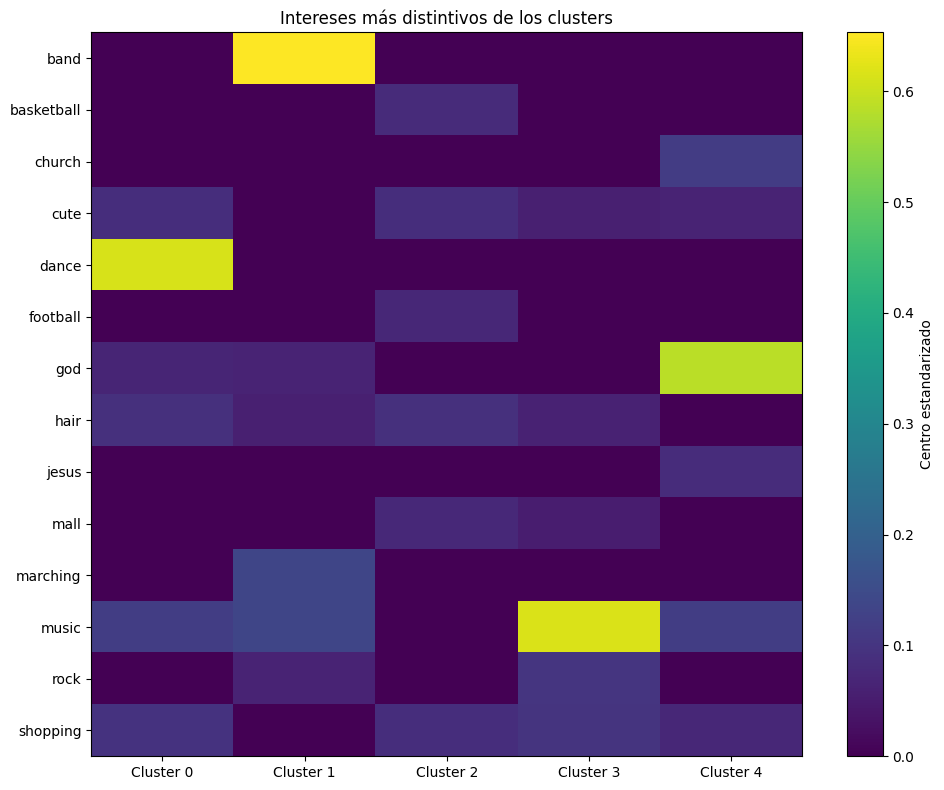

In [12]:
top_features = []

for cluster_id in range(N_CLUSTERS):
    top = centers.loc[cluster_id].sort_values(ascending=False).head(6)
    for feature, score in top.items():
        top_features.append(
            {
                "cluster": cluster_id,
                "interest": feature,
                "score": score,
            }
        )

top_features = pd.DataFrame(top_features)

pivot_top = top_features.pivot(
    index="interest", columns="cluster", values="score"
).fillna(0)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(pivot_top.values, aspect="auto")

ax.set_xticks(range(N_CLUSTERS))
ax.set_xticklabels([f"Cluster {i}" for i in range(N_CLUSTERS)])
ax.set_yticks(range(len(pivot_top.index)))
ax.set_yticklabels(pivot_top.index)

ax.set_title("Intereses más distintivos de los clusters")
fig.colorbar(im, ax=ax, label="Centro estandarizado")

plt.tight_layout()
plt.show()

In [13]:
# Perfil demográfico y social de los segmentos
data["gender_profile"] = data["gender"].fillna("Unknown")

cluster_profile = (
    data.groupby("cluster")
    .agg(
        n=("cluster", "size"),
        age_mean=("age_imputed", "mean"),
        age_median=("age_imputed", "median"),
        friends_mean=("friends", "mean"),
        friends_median=("friends", "median"),
    )
    .round(2)
)

cluster_profile

,n,age_mean,age_median,friends_mean,friends_median
cluster,,,,,
0,3251,17.08,16.97,32.64,22.0
1,2230,17.29,17.34,31.43,21.0
2,17448,17.21,17.20,29.96,19.0
3,3870,17.33,17.38,26.61,18.0
4,3201,17.37,17.45,32.32,22.0


In [14]:
gender_profile = (
    pd.crosstab(
        data["cluster"],
        data["gender_profile"],
        normalize="index",
    )
    .mul(100)
    .round(1)
)

gender_profile

gender_profile,F,M,Unknown
cluster,,,
0,81.6,9.6,8.8
1,69.4,23.9,6.7
2,72.4,17.5,10.1
3,73.0,20.1,6.8
4,75.1,16.7,8.2


Interpretación de los clusters

En la ejecución de referencia con `random_state=42`, los perfiles dominantes son aproximadamente:

 Cluster 0 — Vida social y comportamientos de riesgo
   Los términos más distintivos incluyen
   
                   `kissed`, `sex`, `drugs`, `hair`, `drunk`, `blonde` y `die`.
                   
   Interpretación: perfiles con conversación más intensa alrededor de relaciones, apariencia, vida
   social y comportamientos de riesgo.
   
 Cluster 1 — Moda, marcas y compras
   Destacan
         `hollister`, `abercrombie`, `shopping`, `mall`, `clothes`, `cheerleading`, `hair` y `cute`.
         
   Interpretación: segmento claramente orientado a moda, marcas, centros comerciales y apariencia.
   
 Cluster 2 — Baja intensidad de intereses específicos
   Es el cluster más grande y sus centroides se encuentran, en general, cerca o por debajo del
   promedio en las variables de interés.
   
   Interpretación: usuarios con menor intensidad de señal en las categorías analizadas o con
   intereses menos especializados.
   
 Cluster 3 — Intereses sociales, deportivos y religiosos
   Sobresalen
       `church`, `god`, `shopping`, `basketball`, `jesus`, `cute`, `dance` y `football`.
       
   Interpretación: segmento amplio con una combinación de actividad social, deportes, compras
   y referencias religiosas.
   
 Cluster 4 — Banda y música
   Los términos más distintivos son
                               `marching`, `band` y `music`.
                               
   Interpretación: nicho pequeño y muy especializado alrededor de bandas escolares y
   actividades musicales.
   
NOTA: Los nombres de los segmentos son **etiquetas analíticas construidas después del clustering.
El algoritmo no conoce ni genera estos nombres: estos surgen de la interpretación de los perfiles.


In [15]:
# Tabla resumen para una decisión de marketing

segment_names = {
    0: "Vida social y comportamientos de riesgo",
    1: "Moda, marcas y compras",
    2: "Baja intensidad de intereses específicos",
    3: "Social, deportes y religión",
    4: "Banda y música",
}

summary = cluster_profile.copy()
summary["segment"] = summary.index.map(segment_names)

summary = summary[["segment", "n", "age_mean", "friends_median"]]

summary

,segment,n,age_mean,friends_median
cluster,,,,
0,Vida social y comportamientos de riesgo,3251,17.08,22.0
1,"Moda, marcas y compras",2230,17.29,21.0
2,Baja intensidad de intereses específicos,17448,17.21,19.0
3,"Social, deportes y religión",3870,17.33,18.0
4,Banda y música,3201,17.37,22.0


In [16]:
# Almacena el resultado

output = data.copy()
output["segment"] = output["cluster"].map(segment_names)

output.to_csv(
    "../submission/segmented.csv",
    index=False,
)